# Random Forest und Decision Trees

In [1]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

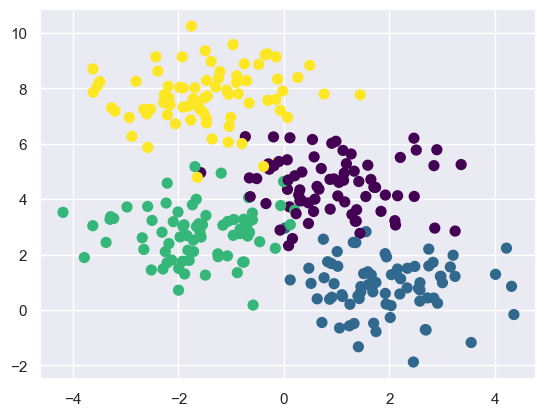

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis');

In [3]:
def visualize_tree(estimator, X, y, boundaries=True,
                   xlim=None, ylim=None, ax=None):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='viridis',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    if xlim is None:
        xlim = ax.get_xlim()
    if ylim is None:
        ylim = ax.get_ylim()
    
    # fit the estimator
    estimator.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    n_classes = len(np.unique(y))
    Z = Z.reshape(xx.shape)
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='viridis', clim=(y.min(), y.max()),
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,
C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,
C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,
C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


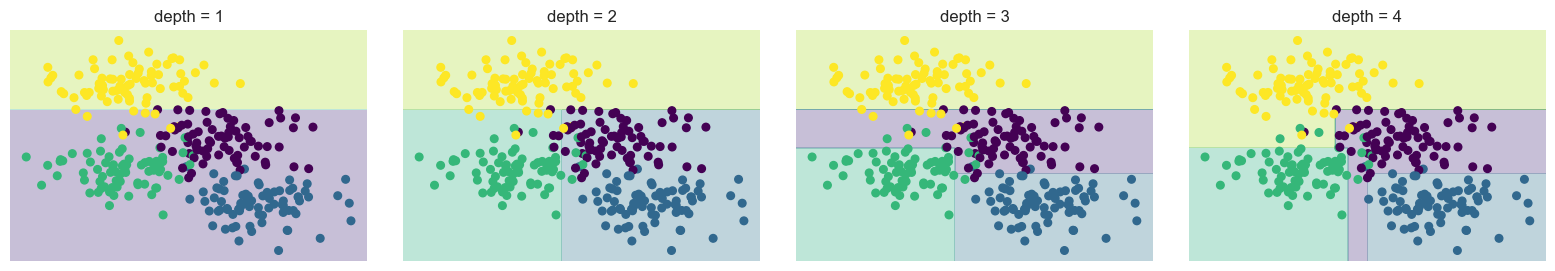

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_blobs

        
fig, ax = plt.subplots(1, 4, figsize=(16, 3))
fig.subplots_adjust(left=0.02, right=0.98, wspace=0.1)

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

for axi, depth in zip(ax, range(1, 5)):
    model = DecisionTreeClassifier(max_depth=depth)
    visualize_tree(model, X, y, ax=axi)
    axi.set_title('depth = {0}'.format(depth))


## Qualitätskriterien: Gini Impurity

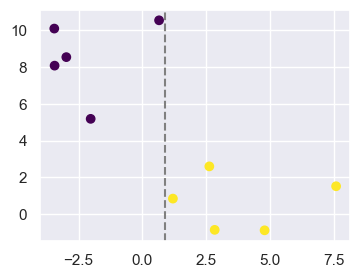

In [5]:
# Import
from sklearn.datasets import make_blobs

# Make blob
X, y = make_blobs(n_samples=10, centers=2,
                  random_state=42, cluster_std=2.)

# Split at 1.2
plt.figure(figsize=(4,3))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.axvline(.9, color='gray', linestyle='--');

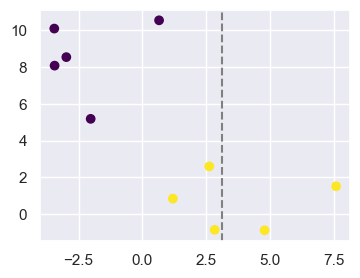

In [6]:
# Split at 0
plt.figure(figsize=(4,3))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.axvline(3.1, color='gray', linestyle='--');

## Entscheidungsbäume: Overfitting

C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,
C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,
C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,
C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


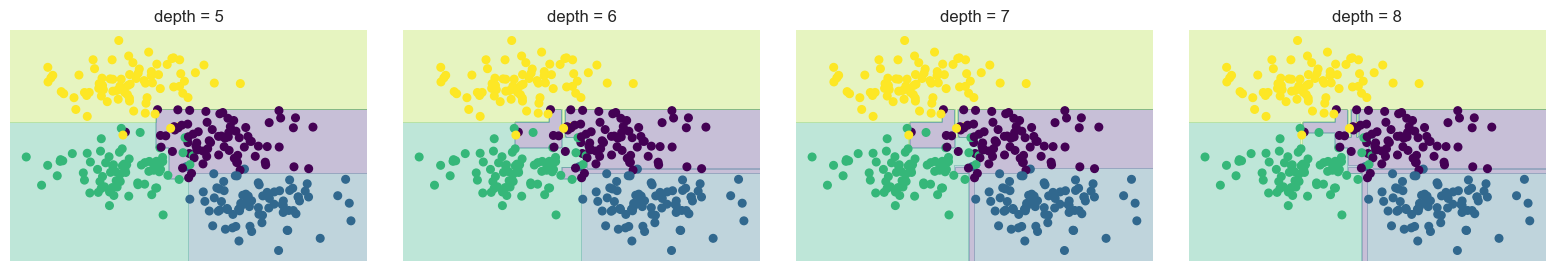

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3))
fig.subplots_adjust(left=0.02, right=0.98, wspace=0.1)

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

for axi, depth in zip(ax, range(5, 9)):
    model = DecisionTreeClassifier(max_depth=depth)
    visualize_tree(model, X, y, ax=axi)
    axi.set_title('depth = {0}'.format(depth))


C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,
C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\3104271112.py:24: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


Text(0.5, 1.0, 'depth = 5')

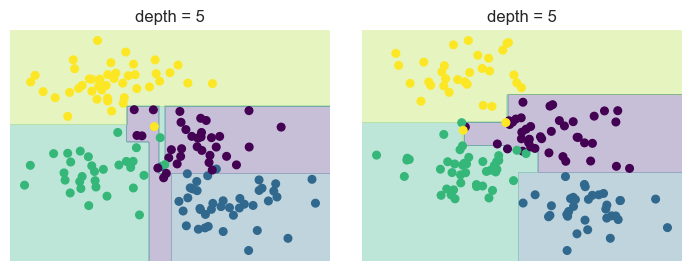

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
fig.subplots_adjust(left=0.02, right=0.98, wspace=0.1)

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

model = DecisionTreeClassifier(max_depth=5)

visualize_tree(model, X[::2], y[::2], ax=ax[0])
ax[0].set_title('depth = {0}'.format(5))

visualize_tree(model, X[1::2], y[1::2], ax=ax[1])
ax[1].set_title('depth = {0}'.format(5))

## Random Forest

In [9]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, clim=(y.min(), y.max()),
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)

C:\Users\gom39655\AppData\Local\Temp\ipykernel_932\520376207.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


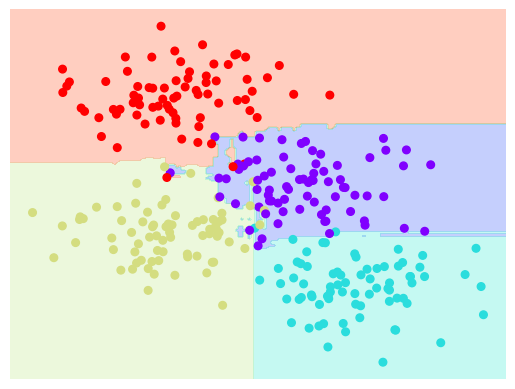

In [11]:
visualize_classifier(model, X, y);

In [12]:
# Import
from sklearn.model_selection import train_test_split

# Split and fit
X_train, X_test, y_train, y_test = train_test_split(X, y)
model.fit(X_train, y_train)

# Calculate class probability
model.predict_proba(X_test)

array([[0.82, 0.12, 0.06, 0.  ],
       [0.  , 0.  , 0.  , 1.  ],
       [0.03, 0.  , 0.01, 0.96],
       [0.  , 0.  , 0.01, 0.99],
       [0.05, 0.  , 0.  , 0.95],
       [0.  , 0.  , 0.02, 0.98],
       [0.01, 0.99, 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  ],
       [0.25, 0.  , 0.  , 0.75],
       [0.95, 0.05, 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  ],
       [0.  , 0.  , 0.01, 0.99],
       [0.  , 0.  , 0.  , 1.  ],
       [0.6 , 0.03, 0.37, 0.  ],
       [0.  , 0.  , 0.  , 1.  ],
       [0.01, 0.  , 0.99, 0.  ],
       [0.07, 0.  , 0.93, 0.  ],
       [0.  , 0.  , 0.02, 0.98],
       [0.  , 0.  , 0.03, 0.97],
       [0.23, 0.74, 0.03, 0.  ],
       [0.  , 0.  , 0.99, 0.01],
       [0.  , 1.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  ],
       [0.81, 0.  , 0.15, 0.04],
       [0.  , 0.  , 0.01, 0.99],
       [0.97, 0.03, 0.  , 0.  ],
       [0.77, 0.  , 0.04, 0.19],
       [0.01, 0.98, 0.01, 0.  ],
       [0.  , 0.  , 0.01, 0.99],
       [0.01, 0.99, 0.  , 0.  ],
       [0.

### Feature Importance

In [13]:
# Import
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
# Make dataset
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=3, n_redundant=0,
    n_repeated=0, n_classes=2, random_state=0, shuffle=False)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42)

# Fit
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [14]:
np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)

array([0.07881329, 0.0547335 , 0.07616586, 0.02275861, 0.0201599 ,
       0.02207782, 0.02506193, 0.02797063, 0.02372194, 0.02413588])

In [15]:
model.feature_importances_

array([0.20944276, 0.31787234, 0.19518962, 0.04039265, 0.03860917,
       0.03406563, 0.04025513, 0.0425733 , 0.0400183 , 0.04158111])

In [16]:
np.array([tree.feature_importances_ for tree in model.estimators_]).std(axis=0)

array([0.07881329, 0.0547335 , 0.07616586, 0.02275861, 0.0201599 ,
       0.02207782, 0.02506193, 0.02797063, 0.02372194, 0.02413588])

In [17]:
model.feature_importances_

array([0.20944276, 0.31787234, 0.19518962, 0.04039265, 0.03860917,
       0.03406563, 0.04025513, 0.0425733 , 0.0400183 , 0.04158111])

In [18]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)
forest_importances = pd.Series(result['importances_mean'])

In [19]:
result

{'importances_mean': array([0.1756, 0.2864, 0.1888, 0.0036, 0.0016, 0.0028, 0.0064, 0.0036,
        0.0072, 0.0024]),
 'importances_std': array([0.01458218, 0.03960606, 0.02275434, 0.0028    , 0.00542586,
        0.0031241 , 0.0051225 , 0.0068    , 0.00299333, 0.0048    ]),
 'importances': array([[ 0.196,  0.172,  0.168,  0.196,  0.172,  0.184,  0.168,  0.172,
          0.144,  0.184],
        [ 0.292,  0.22 ,  0.212,  0.308,  0.324,  0.264,  0.328,  0.32 ,
          0.308,  0.288],
        [ 0.196,  0.188,  0.168,  0.236,  0.212,  0.172,  0.176,  0.2  ,
          0.188,  0.152],
        [ 0.   ,  0.008,  0.004,  0.   ,  0.004,  0.004,  0.004,  0.004,
          0.008,  0.   ],
        [-0.008,  0.008, -0.004, -0.004,  0.004,  0.   ,  0.   ,  0.008,
          0.004,  0.008],
        [ 0.004,  0.004,  0.004,  0.   ,  0.008,  0.004,  0.004,  0.   ,
         -0.004,  0.004],
        [ 0.   ,  0.008,  0.004,  0.008,  0.   ,  0.016,  0.008,  0.012,
          0.   ,  0.008],
        [ 0.008, 

In [20]:
result.importances_mean

array([0.1756, 0.2864, 0.1888, 0.0036, 0.0016, 0.0028, 0.0064, 0.0036,
       0.0072, 0.0024])

In [21]:
result['importances_mean']

array([0.1756, 0.2864, 0.1888, 0.0036, 0.0016, 0.0028, 0.0064, 0.0036,
       0.0072, 0.0024])

In [22]:
pd.Series(result['importances_mean'])

0    0.1756
1    0.2864
2    0.1888
3    0.0036
4    0.0016
5    0.0028
6    0.0064
7    0.0036
8    0.0072
9    0.0024
dtype: float64

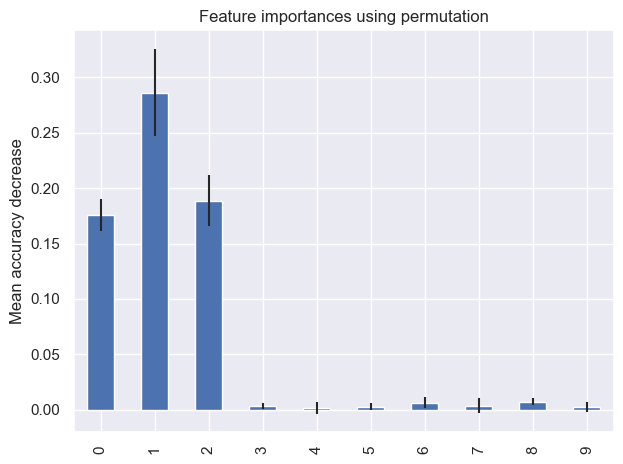

In [23]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

### Random Forest Regression

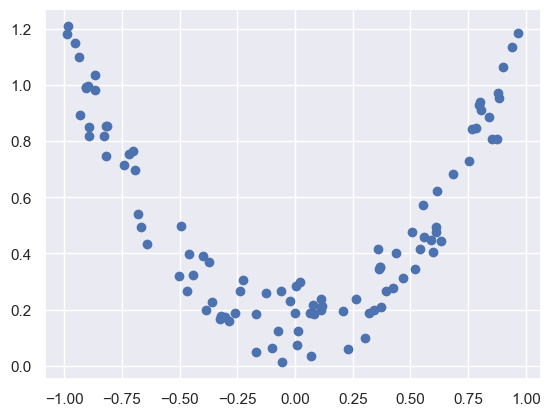

In [2]:
# Import
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Make quadratic data
index = np.random.uniform(-1, 1, size=(100, 1))
data = index ** 2 + np.random.rand(len(index), 1) * .3
plt.scatter(index, data);

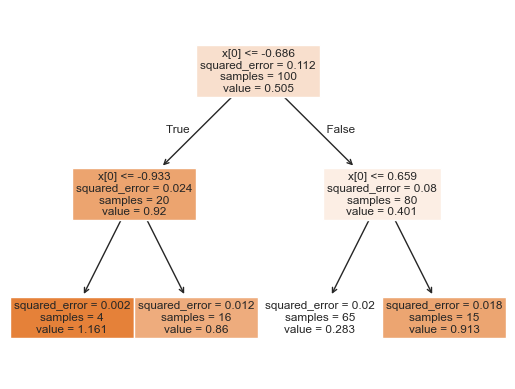

In [3]:
# Fit decision tree regressor
model = DecisionTreeRegressor(max_depth=2, random_state=42)
model.fit(index, data)

# Plot tree
plot_tree(model, filled=True);

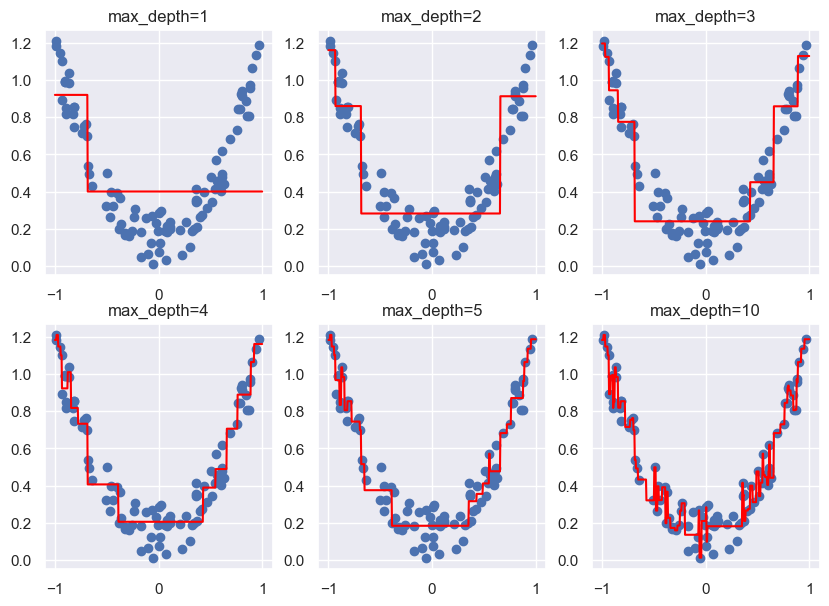

In [4]:
# Fit decision tree regressors
index_predictions = np.linspace(-1, 1, 500).reshape(-1, 1)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flat
for n, max_depth in enumerate([1, 2, 3, 4, 5, 10]):
    model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
    model.fit(index, data)
    
    # Plot predictions
    predictions = model.predict(index_predictions)
    axes[n].scatter(index, data)
    axes[n].plot(index_predictions, predictions, color='red')
    axes[n].set_title(f'max_depth={max_depth}')

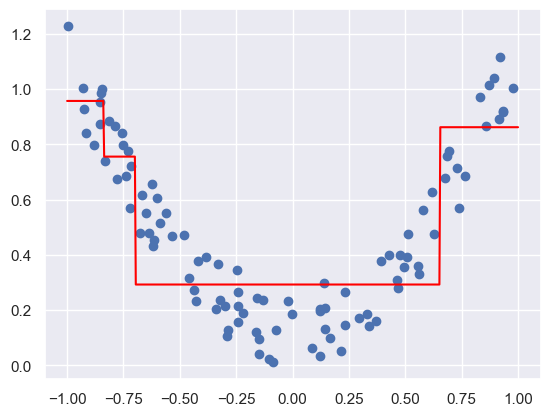

In [27]:
# Fit a decision tree regressor: max_depth=2
model = DecisionTreeRegressor(max_depth=2)
model.fit(index, data)

# Plot predictions: max_depth=2
index_predictions = np.linspace(-1, 1, 500).reshape(-1, 1)
predictions = model.predict(index_predictions)
plt.figure()
plt.scatter(index, data)
plt.plot(index_predictions, predictions, color='red')

In [28]:
def plot_regression_predictions(tree_reg, X, y, axes=[0, 1, -0.2, 1], ylabel="$y$"):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=18)
    if ylabel:
        plt.ylabel(ylabel, fontsize=18, rotation=0)
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

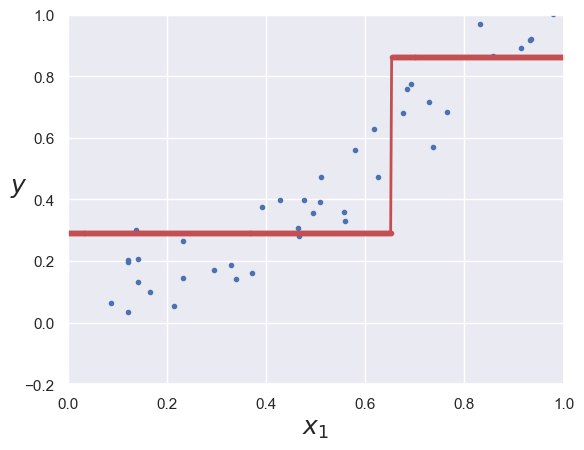

In [29]:
plot_regression_predictions(model, index, data)